<a href="https://colab.research.google.com/github/Mohammed-Twaha/skin-cancer-classification/blob/main/mobilenetv2_vit_swin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install -q kaggle

In [ ]:
!pip install Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"mohammedtwaha08","key":"597594f6fca245cc21223fa9fa32a43c"}'}

In [ ]:
!ls

'kaggle (1).json'   sample_data


In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/
!unzip -q /content/skin-cancer-mnist-ham10000.zip -d /content/ham10000
!ls /content/ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:04<00:00, 18.3MB/s]

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [ ]:
!ls /content/ham10000

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


Device : cuda
Epochs : 20
Batch  : 16
Image directories: [PosixPath('/content/ham10000/HAM10000_images_part_1'), PosixPath('/content/ham10000/ham10000_images_part_1'), PosixPath('/content/ham10000/HAM10000_images_part_2'), PosixPath('/content/ham10000/ham10000_images_part_2')]
Images found: 10015  |  Missing: 0

Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Class counts:
 label_idx
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64

Train: 7002  |  Val: 1519  |  Test: 1494
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]


Loss class weights: [1.058 0.575 0.296 2.46  0.284 0.046 2.281]

────────────────────────────────────────────────────────────
  Training for 20 epochs on cuda
────────────────────────────────────────────────────────────
   Ep    TrLoss   TrAcc   VlLoss   VlAcc    VlF1  LR
    1    0.5159  56.23%   1.8679  34.04%  0.3309  9.94e-05 ★
    2    0.2694  71.42%   1.4881  49.31%  0.4367  9.76e-05 ★
    3    0.1986  77.22%   1.4554  54.44%  0.5078  9.46e-05 ★
    4    0.1654  79.82%   1.3369  55.43%  0.5069  9.05e-05
    5    0.1336  81.95%   1.1959  59.12%  0.5543  8.54e-05 ★
    6    0.1235  83.23%   1.0989  61.62%  0.5633  7.94e-05 ★
    7    0.1088  84.22%   1.1784  59.97%  0.5436  7.27e-05
    8    0.0863  86.66%   0.9316  66.62%  0.6185  6.55e-05 ★
    9    0.0742  87.53%   1.0289  65.31%  0.5841  5.78e-05
   10    0.0738  87.77%   1.0899  63.07%  0.5733  5.00e-05
   11    0.0720  88.45%   1.1378  62.54%  0.5796  4.22e-05
   12    0.0557  88.95%   1.0010  64.32%  0.5893  3.45e-05
   13  

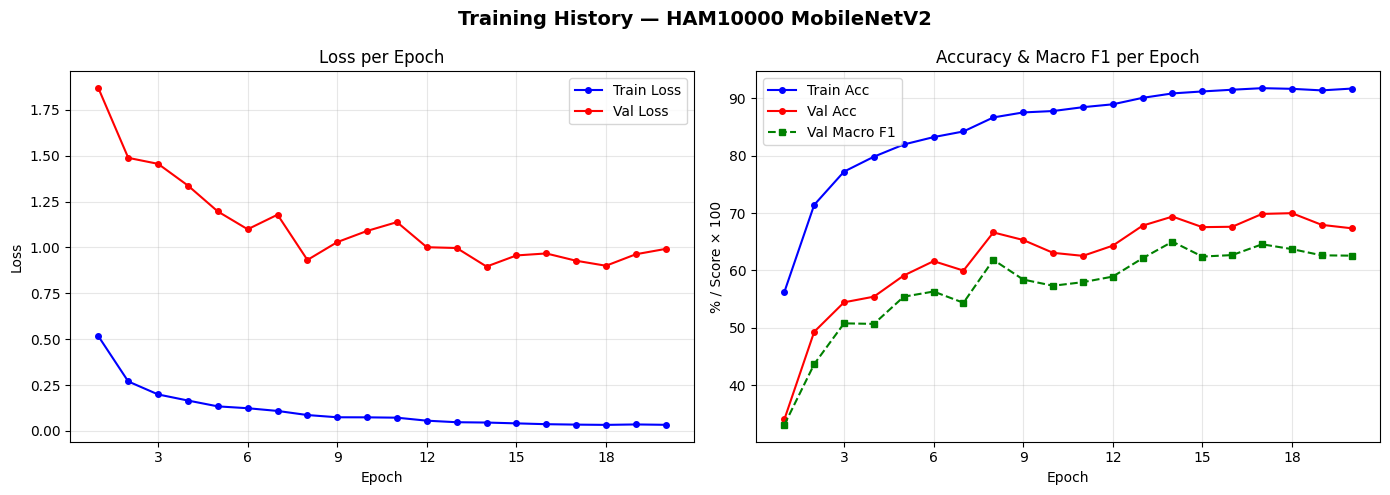

Training curves saved → /content/ham10000/outputs/training_curves.png


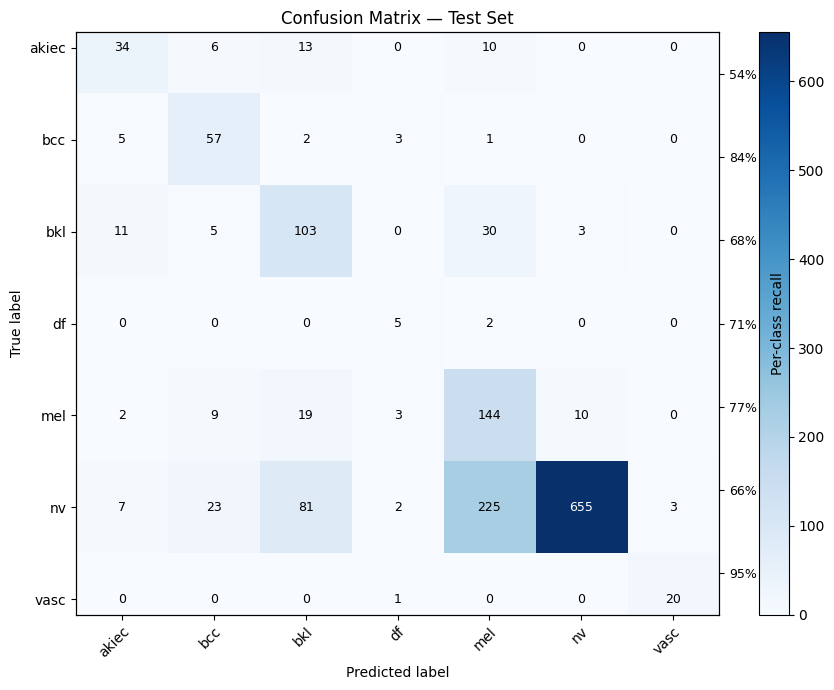

Confusion matrix saved → /content/ham10000/outputs/confusion_matrix_test.png


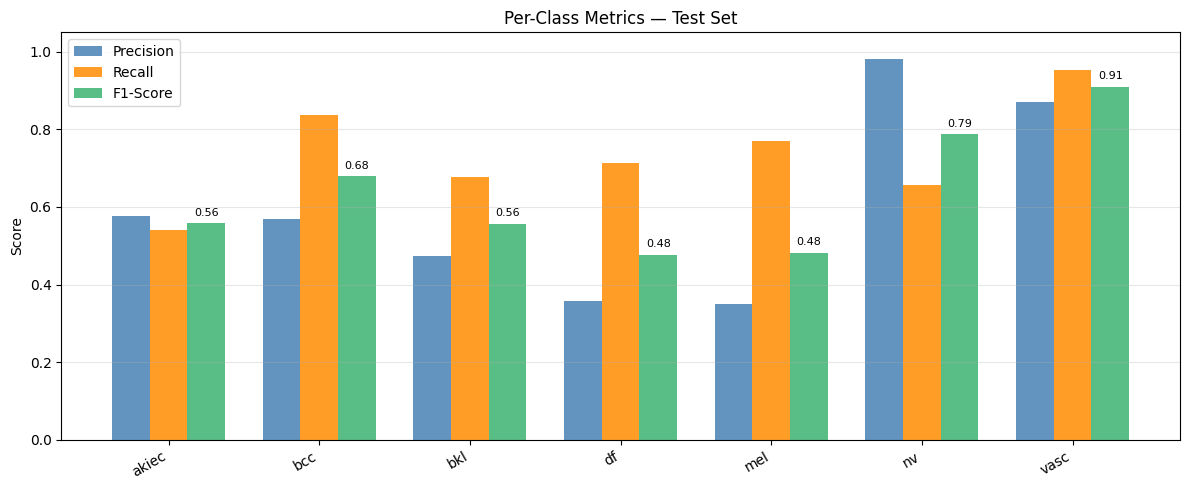

Per-class metrics saved → /content/ham10000/outputs/per_class_metrics_test.png

Generating 8 Grad-CAM overlays …
  [✓] true=nv           pred=nv            → ISIC_0025424_true-nv_pred-nv.jpg
  [✗] true=mel          pred=df            → ISIC_0034064_true-mel_pred-df.jpg
  [✓] true=bkl          pred=bkl           → ISIC_0027218_true-bkl_pred-bkl.jpg
  [✓] true=nv           pred=nv            → ISIC_0032223_true-nv_pred-nv.jpg
  [✓] true=nv           pred=nv            → ISIC_0024690_true-nv_pred-nv.jpg
  [✓] true=nv           pred=nv            → ISIC_0027170_true-nv_pred-nv.jpg
  [✓] true=mel          pred=mel           → ISIC_0026500_true-mel_pred-mel.jpg
  [✓] true=mel          pred=mel           → ISIC_0033047_true-mel_pred-mel.jpg

All outputs saved to: /content/ham10000/outputs


In [ ]:
import os
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cv2

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
DATA_DIR   = Path("/content/ham10000")
META_CSV   = DATA_DIR / "HAM10000_metadata.csv"

NUM_EPOCHS  = 20
BATCH_SIZE  = 16
LR          = 1e-4
IMG_SIZE    = 224
NUM_WORKERS = 2           # set 0 if running on Windows
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR  = DATA_DIR / "outputs"
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
GRADCAM_DIR = OUTPUT_DIR / "gradcam"

for d in [CKPT_DIR, GRADCAM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device : {DEVICE}")
print(f"Epochs : {NUM_EPOCHS}")
print(f"Batch  : {BATCH_SIZE}")


# ─────────────────────────────────────────
# 1. UNZIP  (subprocess, not !unzip)
# ─────────────────────────────────────────
def unzip_if_needed(data_dir: Path):
    for base in ["HAM10000_images_part_1", "HAM10000_images_part_2",
                 "ham10000_images_part_1",  "ham10000_images_part_2"]:
        zip_path = data_dir / f"{base}.zip"
        out_dir  = data_dir / base
        if zip_path.exists() and not out_dir.exists():
            print(f"Unzipping {zip_path} …")
            subprocess.run(
                ["unzip", "-q", str(zip_path), "-d", str(data_dir)],
                check=True
            )


# ─────────────────────────────────────────
# 2. METADATA & DATASET
# ─────────────────────────────────────────
def load_metadata(data_dir: Path):
    if not META_CSV.exists():
        raise FileNotFoundError(f"Metadata CSV not found: {META_CSV}")

    candidates = [
        data_dir / "HAM10000_images_part_1",
        data_dir / "ham10000_images_part_1",
        data_dir / "HAM10000_images_part_2",
        data_dir / "ham10000_images_part_2",
    ]
    img_dirs = [p for p in candidates if p.exists()]
    if not img_dirs:
        raise FileNotFoundError(f"No image folders found. Checked:\n{candidates}")
    print("Image directories:", img_dirs)

    df = pd.read_csv(META_CSV)

    def find_image(image_id):
        fname = f"{image_id}.jpg"
        for d in img_dirs:
            p = d / fname
            if p.exists():
                return str(p)
        return None

    df["image_path"] = df["image_id"].apply(find_image)
    missing = df["image_path"].isna().sum()
    print(f"Images found: {len(df) - missing}  |  Missing: {missing}")
    df = df[df["image_path"].notna()].reset_index(drop=True)

    labels        = sorted(df["dx"].unique())
    label_to_idx  = {lbl: i for i, lbl in enumerate(labels)}
    df["label_idx"] = df["dx"].map(label_to_idx)

    print("\nClasses:", label_to_idx)
    print("Class counts:\n", df["label_idx"].value_counts().sort_index())
    return df, label_to_idx, labels


class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label_idx"])
        path  = row["image_path"]
        img   = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path


def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tfms, test_tfms


def make_splits(df):
    """
    Patient-safe split: all images from the same lesion_id go to the
    same split, preventing data leakage.
    """
    groups = df["lesion_id"].values

    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss_outer.split(df, groups=groups))
    train_df = df.iloc[train_idx]
    temp_df  = df.iloc[temp_idx]

    gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    temp_groups = temp_df["lesion_id"].values
    val_idx, test_idx = next(gss_inner.split(temp_df, groups=temp_groups))
    val_df  = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

    print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
    return train_df.reset_index(drop=True), \
           val_df.reset_index(drop=True), \
           test_df.reset_index(drop=True)


def make_weighted_sampler(train_df, num_classes):
    """Over-sample minority classes so each mini-batch is class-balanced."""
    counts      = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    class_w     = 1.0 / counts
    sample_w    = train_df["label_idx"].map(lambda i: class_w[i]).values
    sampler     = WeightedRandomSampler(
        weights     = torch.from_numpy(sample_w).float(),
        num_samples = len(train_df),
        replacement = True,
    )
    return sampler


# ─────────────────────────────────────────
# 3. MODEL
# ─────────────────────────────────────────
def build_model(num_classes):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1
    model   = mobilenet_v2(weights=weights)
    in_feat = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_feat, num_classes)
    return model


# ─────────────────────────────────────────
# 4. CLASS WEIGHTS  (for loss function)
# ─────────────────────────────────────────
def compute_class_weights(train_df, num_classes):
    counts  = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    print("Loss class weights:", np.round(weights, 3))
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# ─────────────────────────────────────────
# 5. TRAIN / EVALUATE  (with accuracy)
# ─────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0

    for imgs, labels, _ in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0
    all_labels   = []
    all_preds    = []

    # We need loss during validation too
    criterion_eval = nn.CrossEntropyLoss()   # unweighted, just for monitoring

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)
            loss    = criterion_eval(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    report   = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    conf_mat = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, report, conf_mat


# ─────────────────────────────────────────
# 6. PRINTING RESULTS
# ─────────────────────────────────────────
def print_report(report, labels, split="Test"):
    bar = "=" * 55
    print(f"\n{bar}")
    print(f"  {split} Results")
    print(bar)
    print(f"  {'Class':<22} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Sup':>6}")
    print(f"  {'-'*48}")
    for i, lbl in enumerate(labels):
        r = report[str(i)]
        print(
            f"  {lbl:<22} "
            f"{r['precision']:>6.3f} "
            f"{r['recall']:>6.3f} "
            f"{r['f1-score']:>6.3f} "
            f"{int(r['support']):>6}"
        )
    print(f"  {'-'*48}")
    print(f"  Accuracy          : {report['accuracy']:.4f}  ({report['accuracy']*100:.2f}%)")
    print(f"  Macro F1          : {report['macro avg']['f1-score']:.4f}")
    print(f"  Weighted F1       : {report['weighted avg']['f1-score']:.4f}")
    print(f"  Macro Precision   : {report['macro avg']['precision']:.4f}")
    print(f"  Macro Recall      : {report['macro avg']['recall']:.4f}")
    print(bar)


# ─────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────
def plot_training_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History — HAM10000 MobileNetV2", fontsize=14, fontweight="bold")

    # Loss
    ax = axes[0]
    ax.plot(epochs, history["train_loss"], "b-o", label="Train Loss",  markersize=4)
    ax.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",    markersize=4)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss per Epoch")
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot(epochs, [a * 100 for a in history["train_acc"]], "b-o", label="Train Acc", markersize=4)
    ax.plot(epochs, [a * 100 for a in history["val_acc"]],   "r-o", label="Val Acc",   markersize=4)
    ax.plot(epochs, [f * 100 for f in history["val_macro_f1"]], "g--s", label="Val Macro F1", markersize=4)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("% / Score × 100")
    ax.set_title("Accuracy & Macro F1 per Epoch")
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {save_path}")


def plot_confusion_matrix(cm, labels, save_path, title="Confusion Matrix — Test Set"):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks     = np.arange(len(labels)),
        yticks     = np.arange(len(labels)),
        xticklabels= labels,
        yticklabels= labels,
        ylabel     = "True label",
        xlabel     = "Predicted label",
        title      = title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9,
            )

    # Diagonal accuracy per class
    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(np.arange(len(labels)))
    ax2.set_yticklabels([f"{a:.0%}" for a in per_class_acc], fontsize=9)
    ax2.set_ylabel("Per-class recall", labelpad=10)

    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix saved → {save_path}")


def plot_per_class_bar(report, labels, save_path):
    """Bar chart of precision / recall / F1 per class."""
    x      = np.arange(len(labels))
    width  = 0.25
    prec   = [report[str(i)]["precision"] for i in range(len(labels))]
    rec    = [report[str(i)]["recall"]    for i in range(len(labels))]
    f1s    = [report[str(i)]["f1-score"]  for i in range(len(labels))]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec, width, label="Precision", color="steelblue",    alpha=0.85)
    ax.bar(x,          rec,  width, label="Recall",    color="darkorange",   alpha=0.85)
    ax.bar(x + width, f1s,  width, label="F1-Score",  color="mediumseagreen", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Metrics — Test Set")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Add accuracy text on top of each F1 bar
    for i, v in enumerate(f1s):
        ax.text(x[i] + width, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Per-class metrics saved → {save_path}")


# ─────────────────────────────────────────
# 8. GRAD-CAM  (all bugs fixed)
# ─────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer_name: str):
        self.model      = model
        self.gradient   = None
        self.activation = None

        named_modules = dict(model.named_modules())
        if target_layer_name not in named_modules:
            raise ValueError(
                f"Layer '{target_layer_name}' not found. "
                f"Available: {list(named_modules.keys())[:20]} …"
            )
        target_layer = named_modules[target_layer_name]
        target_layer.register_forward_hook(self._forward_hook)
        # FIX: use register_full_backward_hook (not deprecated)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activation = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradient = grad_out[0].detach()

    def generate(self, input_tensor, target_class=None):
        """Returns (cam, predicted_class_idx)."""
        self.model.eval()
        # FIX: must enable grad even though model is in eval mode
        with torch.enable_grad():
            self.model.zero_grad()
            output = self.model(input_tensor)

            if target_class is None:
                target_class = output.argmax(dim=1).item()

            score = output[0, target_class]
            score.backward()

        grad = self.gradient      # shape: (1, C, H, W)
        act  = self.activation    # shape: (1, C, H, W)

        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * act).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)

        return cam, target_class   # FIX: return predicted class so caller doesn't need second forward pass


def overlay_gradcam(img_tensor, cam, save_path):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    H, W = img.shape[:2]
    cam_np = cam.squeeze().cpu().numpy()
    cam_np = cv2.resize(cam_np, (W, H))

    heatmap = (cam_np * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    cv2.imwrite(str(save_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


def generate_gradcam_examples(model, dataset, labels, num_samples=8):
    # MobileNetV2: last conv block before the classifier
    gradcam = GradCAM(model, target_layer_name="features.18")
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    print(f"\nGenerating {len(indices)} Grad-CAM overlays …")
    for idx in indices:
        img_tensor, true_label, path = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        # FIX: second forward pass eliminated — generate() returns pred class
        cam, pred_class = gradcam.generate(input_tensor)

        stem      = Path(path).stem
        save_path = GRADCAM_DIR / (
            f"{stem}_true-{labels[true_label]}_pred-{labels[pred_class]}.jpg"
        )
        overlay_gradcam(img_tensor, cam, save_path)
        status = "✓" if pred_class == true_label else "✗"
        print(f"  [{status}] true={labels[true_label]:<12} pred={labels[pred_class]:<12}  → {save_path.name}")


# ─────────────────────────────────────────
# 9. MAIN
# ─────────────────────────────────────────
def main():
    # --- Setup ---
    unzip_if_needed(DATA_DIR)
    df, label_to_idx, labels = load_metadata(DATA_DIR)
    num_classes = len(labels)

    train_df, val_df, test_df = make_splits(df)

    train_tfms, test_tfms = get_transforms()
    train_dataset = SkinDataset(train_df, transform=train_tfms)
    val_dataset   = SkinDataset(val_df,   transform=test_tfms)
    test_dataset  = SkinDataset(test_df,  transform=test_tfms)

    sampler = make_weighted_sampler(train_df, num_classes)
    train_loader = DataLoader(
        train_dataset,
        batch_size  = BATCH_SIZE,
        sampler     = sampler,           # replaces shuffle=True
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )
    val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # --- Model, Loss, Optimizer, Scheduler ---
    model         = build_model(num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_df, num_classes)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    optimizer     = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # --- Training loop ---
    best_val_macro_f1 = 0.0
    best_ckpt         = CKPT_DIR / "mobilenetv2_ham10000_best.pth"

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "val_macro_f1": [],
    }

    print(f"\n{'─'*60}")
    print(f"  Training for {NUM_EPOCHS} epochs on {DEVICE}")
    print(f"{'─'*60}")
    print(f"  {'Ep':>3}  {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlF1':>7}  LR")

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_report, _ = evaluate(model, val_loader)
        vl_macro_f1 = vl_report["macro avg"]["f1-score"]

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_macro_f1"].append(vl_macro_f1)

        marker = " ★" if vl_macro_f1 > best_val_macro_f1 else ""
        print(
            f"  {epoch:>3}  {tr_loss:>8.4f} {tr_acc*100:>6.2f}%"
            f" {vl_loss:>8.4f} {vl_acc*100:>6.2f}%"
            f" {vl_macro_f1:>7.4f}  {current_lr:.2e}{marker}"
        )

        if vl_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = vl_macro_f1
            torch.save(model.state_dict(), best_ckpt)

    print(f"\nBest val macro F1: {best_val_macro_f1:.4f}")
    print(f"Checkpoint saved  : {best_ckpt}")

    # --- Load best model & evaluate on test set ---
    # FIX: weights_only=True (PyTorch ≥ 2.0 safe deserialization)
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))

    _, test_acc, test_report, test_cm = evaluate(model, test_loader)
    print_report(test_report, labels, split="Test")

    # --- Save all plots ---
    plot_training_curves(
        history,
        save_path=OUTPUT_DIR / "training_curves.png"
    )
    plot_confusion_matrix(
        test_cm, labels,
        save_path=OUTPUT_DIR / "confusion_matrix_test.png"
    )
    plot_per_class_bar(
        test_report, labels,
        save_path=OUTPUT_DIR / "per_class_metrics_test.png"
    )

    # --- Grad-CAM examples ---
    generate_gradcam_examples(model, test_dataset, labels, num_samples=8)

    print("\nAll outputs saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

Device : cuda
Epochs : 20
Batch  : 16
Image directories: [PosixPath('/content/ham10000/HAM10000_images_part_1'), PosixPath('/content/ham10000/ham10000_images_part_1'), PosixPath('/content/ham10000/HAM10000_images_part_2'), PosixPath('/content/ham10000/ham10000_images_part_2')]
Images found: 10015  |  Missing: 0

Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Class counts:
 label_idx
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64

Train: 7002  |  Val: 1519  |  Test: 1494
Loss class weights: [1.058 0.575 0.296 2.46  0.284 0.046 2.281]

─────────────────────────────────────────────────────────────────
  Training ViT-B/16 for 20 epochs on cuda
─────────────────────────────────────────────────────────────────
   Ep    TrLoss   TrAcc   VlLoss   VlAcc    VlF1  LR
    1    0.5505  57.63%   2.0267  36.54%  0.2937  9.94e-05 ★
    2    0.3029  71.48%   1.5501  49.84%  0.4765  9.76e-05 ★
    3    0.1869  78.25%   1.

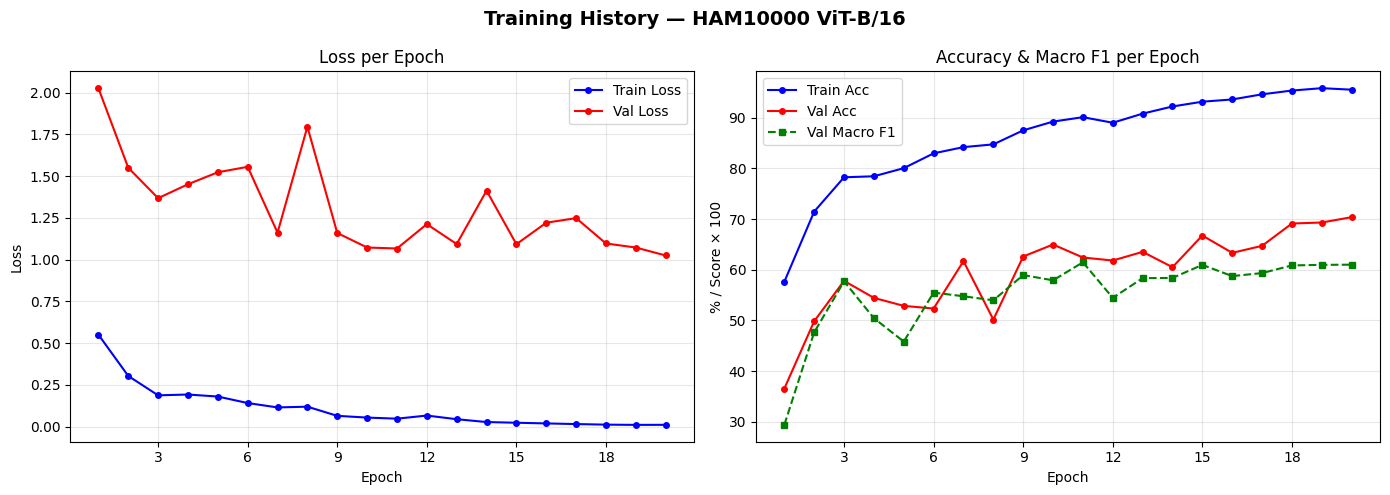

Training curves saved → /content/ham10000/outputs/training_curves.png


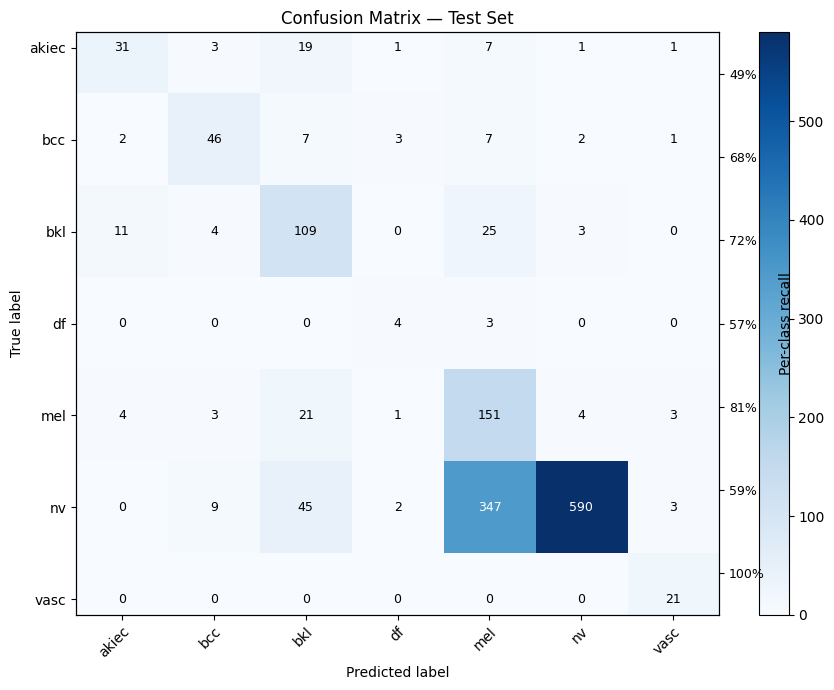

Confusion matrix saved → /content/ham10000/outputs/confusion_matrix_test.png


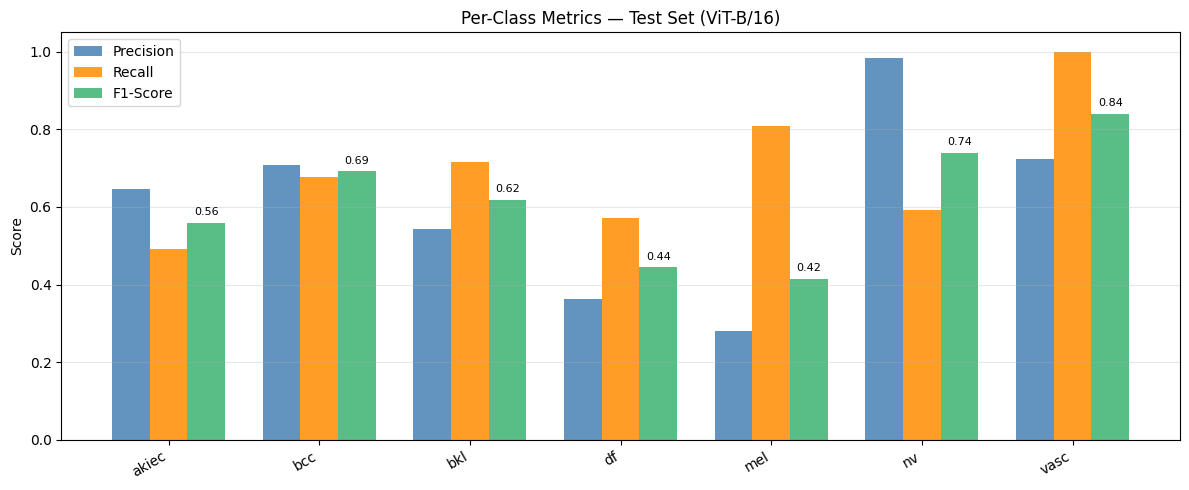

Per-class metrics saved → /content/ham10000/outputs/per_class_metrics_test.png

Generating 8 attention rollout overlays …
  [✗] true=nv           pred=mel           → ISIC_0025424_true-nv_pred-mel.jpg
  [✗] true=mel          pred=df            → ISIC_0034064_true-mel_pred-df.jpg
  [✗] true=bkl          pred=mel           → ISIC_0027218_true-bkl_pred-mel.jpg
  [✓] true=nv           pred=nv            → ISIC_0032223_true-nv_pred-nv.jpg
  [✗] true=nv           pred=bkl           → ISIC_0024690_true-nv_pred-bkl.jpg
  [✓] true=nv           pred=nv            → ISIC_0027170_true-nv_pred-nv.jpg
  [✓] true=mel          pred=mel           → ISIC_0026500_true-mel_pred-mel.jpg
  [✓] true=mel          pred=mel           → ISIC_0033047_true-mel_pred-mel.jpg

All outputs saved to: /content/ham10000/outputs


In [ ]:
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cv2

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
DATA_DIR   = Path("/content/ham10000")
META_CSV   = DATA_DIR / "HAM10000_metadata.csv"

NUM_EPOCHS  = 20
BATCH_SIZE  = 16         # lower to 16 if Colab runs out of VRAM (ViT is heavier)
LR          = 1e-4       # ViT is sensitive to LR — keep low
IMG_SIZE    = 224        # ViT-B/16 requires 224×224
NUM_WORKERS = 2
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR  = DATA_DIR / "outputs"
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
ATTN_DIR    = OUTPUT_DIR / "attention_maps"

for d in [CKPT_DIR, ATTN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device : {DEVICE}")
print(f"Epochs : {NUM_EPOCHS}")
print(f"Batch  : {BATCH_SIZE}")


# ─────────────────────────────────────────
# 1. UNZIP  (subprocess — works as .py file)
# ─────────────────────────────────────────
def unzip_if_needed(data_dir: Path):
    for base in ["HAM10000_images_part_1", "HAM10000_images_part_2",
                 "ham10000_images_part_1",  "ham10000_images_part_2"]:
        zip_path = data_dir / f"{base}.zip"
        out_dir  = data_dir / base
        if zip_path.exists() and not out_dir.exists():
            print(f"Unzipping {zip_path} …")
            subprocess.run(
                ["unzip", "-q", str(zip_path), "-d", str(data_dir)],
                check=True
            )


# ─────────────────────────────────────────
# 2. METADATA & DATASET
# ─────────────────────────────────────────
def load_metadata(data_dir: Path):
    if not META_CSV.exists():
        raise FileNotFoundError(f"Metadata CSV not found: {META_CSV}")

    candidates = [
        data_dir / "HAM10000_images_part_1",
        data_dir / "ham10000_images_part_1",
        data_dir / "HAM10000_images_part_2",
        data_dir / "ham10000_images_part_2",
    ]
    img_dirs = [p for p in candidates if p.exists()]
    if not img_dirs:
        raise FileNotFoundError(f"No image folders found. Checked:\n{candidates}")
    print("Image directories:", img_dirs)

    df = pd.read_csv(META_CSV)

    def find_image(image_id):
        fname = f"{image_id}.jpg"
        for d in img_dirs:
            p = d / fname
            if p.exists():
                return str(p)
        return None

    df["image_path"] = df["image_id"].apply(find_image)
    missing = df["image_path"].isna().sum()
    print(f"Images found: {len(df) - missing}  |  Missing: {missing}")
    df = df[df["image_path"].notna()].reset_index(drop=True)

    labels       = sorted(df["dx"].unique())
    label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
    df["label_idx"] = df["dx"].map(label_to_idx)

    print("\nClasses:", label_to_idx)
    print("Class counts:\n", df["label_idx"].value_counts().sort_index())
    return df, label_to_idx, labels


class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label_idx"])
        path  = row["image_path"]
        img   = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path


def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tfms, test_tfms


def make_splits(df):
    """
    Patient-safe split: all images from the same lesion_id go to the
    same split, preventing data leakage across train/val/test.
    """
    groups = df["lesion_id"].values

    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss_outer.split(df, groups=groups))
    train_df = df.iloc[train_idx]
    temp_df  = df.iloc[temp_idx]

    gss_inner  = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    temp_groups = temp_df["lesion_id"].values
    val_idx, test_idx = next(gss_inner.split(temp_df, groups=temp_groups))
    val_df  = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

    print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))


def make_weighted_sampler(train_df):
    """Over-sample minority classes so each mini-batch is more balanced."""
    counts   = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    class_w  = 1.0 / counts
    sample_w = train_df["label_idx"].map(lambda i: class_w[i]).values
    return WeightedRandomSampler(
        weights     = torch.from_numpy(sample_w).float(),
        num_samples = len(train_df),
        replacement = True,
    )


# ─────────────────────────────────────────
# 3. MODEL: Vision Transformer ViT-B/16
# ─────────────────────────────────────────
def build_model(num_classes):
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    model   = vit_b_16(weights=weights)
    in_feat = model.heads.head.in_features
    model.heads.head = nn.Linear(in_feat, num_classes)
    return model


# ─────────────────────────────────────────
# 4. CLASS WEIGHTS  (for loss function)
# ─────────────────────────────────────────
def compute_class_weights(train_df, num_classes):
    counts  = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    print("Loss class weights:", np.round(weights, 3))
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# ─────────────────────────────────────────
# 5. TRAIN / EVALUATE  (with loss + accuracy)
# ─────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for imgs, labels, _ in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0
    all_labels   = []
    all_preds    = []

    criterion_eval = nn.CrossEntropyLoss()   # unweighted for monitoring

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)
            loss    = criterion_eval(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    report     = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    conf_mat   = confusion_matrix(all_labels, all_preds)

    return running_loss / total, correct / total, report, conf_mat


# ─────────────────────────────────────────
# 6. PRINTING RESULTS
# ─────────────────────────────────────────
def print_report(report, labels, split="Test"):
    bar = "=" * 55
    print(f"\n{bar}")
    print(f"  {split} Results")
    print(bar)
    print(f"  {'Class':<22} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Sup':>6}")
    print(f"  {'-'*48}")
    for i, lbl in enumerate(labels):
        r = report[str(i)]
        print(
            f"  {lbl:<22} "
            f"{r['precision']:>6.3f} "
            f"{r['recall']:>6.3f} "
            f"{r['f1-score']:>6.3f} "
            f"{int(r['support']):>6}"
        )
    print(f"  {'-'*48}")
    print(f"  Accuracy          : {report['accuracy']:.4f}  ({report['accuracy']*100:.2f}%)")
    print(f"  Macro F1          : {report['macro avg']['f1-score']:.4f}")
    print(f"  Weighted F1       : {report['weighted avg']['f1-score']:.4f}")
    print(f"  Macro Precision   : {report['macro avg']['precision']:.4f}")
    print(f"  Macro Recall      : {report['macro avg']['recall']:.4f}")
    print(bar)


# ─────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────
def plot_training_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History — HAM10000 ViT-B/16", fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    ax.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Loss per Epoch"); ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, [a * 100 for a in history["train_acc"]], "b-o", label="Train Acc",    markersize=4)
    ax.plot(epochs, [a * 100 for a in history["val_acc"]],   "r-o", label="Val Acc",      markersize=4)
    ax.plot(epochs, [f * 100 for f in history["val_macro_f1"]], "g--s", label="Val Macro F1", markersize=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("% / Score × 100")
    ax.set_title("Accuracy & Macro F1 per Epoch"); ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {save_path}")


def plot_confusion_matrix(cm, labels, save_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(len(labels)),
        yticks      = np.arange(len(labels)),
        xticklabels = labels,
        yticklabels = labels,
        ylabel      = "True label",
        xlabel      = "Predicted label",
        title       = "Confusion Matrix — Test Set",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > thresh else "black")

    # Right axis: per-class recall
    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(np.arange(len(labels)))
    ax2.set_yticklabels([f"{a:.0%}" for a in per_class_acc], fontsize=9)
    ax2.set_ylabel("Per-class recall", labelpad=10)

    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix saved → {save_path}")


def plot_per_class_bar(report, labels, save_path):
    x     = np.arange(len(labels))
    width = 0.25
    prec  = [report[str(i)]["precision"] for i in range(len(labels))]
    rec   = [report[str(i)]["recall"]    for i in range(len(labels))]
    f1s   = [report[str(i)]["f1-score"]  for i in range(len(labels))]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec, width, label="Precision",  color="steelblue",     alpha=0.85)
    ax.bar(x,          rec,  width, label="Recall",     color="darkorange",    alpha=0.85)
    ax.bar(x + width, f1s,  width, label="F1-Score",   color="mediumseagreen", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Metrics — Test Set (ViT-B/16)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    for i, v in enumerate(f1s):
        ax.text(x[i] + width, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Per-class metrics saved → {save_path}")


# ─────────────────────────────────────────
# 8. ATTENTION ROLLOUT VISUALIZATION
#    (ViT equivalent of Grad-CAM)
#    ViT has no convolutional layers, so standard Grad-CAM doesn't apply.
#    Attention Rollout multiplies attention weights across all 12 layers
#    to show which image patches the model attends to.
# ─────────────────────────────────────────
class AttentionRollout:
    def __init__(self, model, discard_ratio=0.9):
        self.model         = model
        self.discard_ratio = discard_ratio
        self.attentions    = []
        self._hooks        = []

        for block in self.model.encoder.layers:
            hook = block.self_attention.register_forward_hook(self._attn_hook)
            self._hooks.append(hook)

    def _attn_hook(self, module, inp, out):
        # out[1] is None by default in PyTorch's MultiheadAttention
        # We must recompute attention weights manually from the input
        q, k, v = inp[0], inp[0], inp[0]   # self-attention: q=k=v=same input
        B, N, C = q.shape
        num_heads   = module.num_heads
        head_dim    = C // num_heads
        scale       = head_dim ** -0.5

        # Use the module's in_proj_weight to get Q, K, V projections
        qkv = torch.nn.functional.linear(q, module.in_proj_weight, module.in_proj_bias)
        qkv = qkv.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
        q_, k_, v_ = qkv.unbind(0)   # each: (B, heads, N, head_dim)

        attn = (q_ @ k_.transpose(-2, -1)) * scale
        attn = attn.softmax(dim=-1)   # (B, heads, N, N)

        self.attentions.append(attn.detach().cpu())

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

    def __call__(self, input_tensor):
        self.attentions = []
        self.model.eval()
        with torch.no_grad():
            output = self.model(input_tensor)

        pred_class = output.argmax(dim=1).item()

        result = None
        for attn in self.attentions:
            attn_avg  = attn.mean(dim=1)                          # (B, N, N)
            attn_avg  = attn_avg + torch.eye(attn_avg.size(-1))   # add residual
            attn_avg  = attn_avg / attn_avg.sum(dim=-1, keepdim=True)

            flat      = attn_avg.view(attn_avg.size(0), -1)
            threshold = flat.quantile(self.discard_ratio, dim=-1, keepdim=True).unsqueeze(-1)
            attn_avg  = torch.where(attn_avg >= threshold, attn_avg, torch.zeros_like(attn_avg))

            result = attn_avg if result is None else torch.bmm(attn_avg, result)

        mask     = result[0, 0, 1:]              # CLS row, drop CLS token itself
        grid     = int(mask.shape[0] ** 0.5)     # 14 for ViT-B/16 (196 patches)
        mask     = mask.reshape(grid, grid).numpy()
        mask     = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask, pred_class


def save_attention_overlay(img_tensor, mask, save_path, img_size=224):
    """Overlay the attention rollout heatmap on the original image."""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    heatmap = cv2.resize(mask, (img_size, img_size))
    heatmap = (heatmap * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.55, heatmap, 0.45, 0)

    cv2.imwrite(str(save_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


def generate_attention_examples(model, dataset, labels, num_samples=8):
    rollout = AttentionRollout(model, discard_ratio=0.9)
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    print(f"\nGenerating {len(indices)} attention rollout overlays …")
    for idx in indices:
        img_tensor, true_label, path = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        mask, pred_class = rollout(input_tensor)

        stem      = Path(path).stem
        save_path = ATTN_DIR / (
            f"{stem}_true-{labels[true_label]}_pred-{labels[pred_class]}.jpg"
        )
        save_attention_overlay(img_tensor, mask, save_path)
        status = "✓" if pred_class == true_label else "✗"
        print(f"  [{status}] true={labels[true_label]:<12} pred={labels[pred_class]:<12}  → {save_path.name}")

    rollout.remove_hooks()


# ─────────────────────────────────────────
# 9. MAIN
# ─────────────────────────────────────────
def main():
    # --- Setup ---
    unzip_if_needed(DATA_DIR)
    df, label_to_idx, labels = load_metadata(DATA_DIR)
    num_classes = len(labels)

    train_df, val_df, test_df = make_splits(df)

    train_tfms, test_tfms = get_transforms()
    train_dataset = SkinDataset(train_df, transform=train_tfms)
    val_dataset   = SkinDataset(val_df,   transform=test_tfms)
    test_dataset  = SkinDataset(test_df,  transform=test_tfms)

    sampler = make_weighted_sampler(train_df)
    train_loader = DataLoader(
        train_dataset,
        batch_size  = BATCH_SIZE,
        sampler     = sampler,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )
    val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # --- Model, Loss, Optimizer, Scheduler ---
    model         = build_model(num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_df, num_classes)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)

    # ViT needs weight_decay — it overfits quickly without it
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # --- Training loop ---
    best_val_macro_f1 = 0.0
    # FIX: checkpoint filename now says vit, not mobilenetv2
    best_ckpt = CKPT_DIR / "vit_b16_ham10000_best.pth"

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "val_macro_f1": [],
    }

    print(f"\n{'─'*65}")
    print(f"  Training ViT-B/16 for {NUM_EPOCHS} epochs on {DEVICE}")
    print(f"{'─'*65}")
    print(f"  {'Ep':>3}  {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlF1':>7}  LR")

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc              = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_report, _ = evaluate(model, val_loader)
        vl_macro_f1                  = vl_report["macro avg"]["f1-score"]

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_macro_f1"].append(vl_macro_f1)

        marker = " ★" if vl_macro_f1 > best_val_macro_f1 else ""
        print(
            f"  {epoch:>3}  {tr_loss:>8.4f} {tr_acc*100:>6.2f}%"
            f" {vl_loss:>8.4f} {vl_acc*100:>6.2f}%"
            f" {vl_macro_f1:>7.4f}  {current_lr:.2e}{marker}"
        )

        if vl_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = vl_macro_f1
            torch.save(model.state_dict(), best_ckpt)

    print(f"\nBest val macro F1 : {best_val_macro_f1:.4f}")
    print(f"Checkpoint saved  : {best_ckpt}")

    # --- Load best model & test ---
    # FIX: weights_only=True (safe deserialization, PyTorch >= 2.0)
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))

    _, test_acc, test_report, test_cm = evaluate(model, test_loader)
    print_report(test_report, labels, split="Test")

    # --- Save all plots ---
    plot_training_curves(history,    save_path=OUTPUT_DIR / "training_curves.png")
    plot_confusion_matrix(test_cm, labels, save_path=OUTPUT_DIR / "confusion_matrix_test.png")
    plot_per_class_bar(test_report, labels, save_path=OUTPUT_DIR / "per_class_metrics_test.png")

    # --- Attention rollout visualization ---
    generate_attention_examples(model, test_dataset, labels, num_samples=8)

    print("\nAll outputs saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

Device : cuda
Epochs : 20
Batch  : 16
Image directories: [PosixPath('/content/ham10000/HAM10000_images_part_1'), PosixPath('/content/ham10000/ham10000_images_part_1'), PosixPath('/content/ham10000/HAM10000_images_part_2'), PosixPath('/content/ham10000/ham10000_images_part_2')]
Images found: 10015  |  Missing: 0

Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Class counts:
 label_idx
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64

Train: 7002  |  Val: 1519  |  Test: 1494
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:02<00:00, 46.2MB/s]


Loss class weights: [1.058 0.575 0.296 2.46  0.284 0.046 2.281]

─────────────────────────────────────────────────────────────────
  Training Swin-T for 20 epochs on cuda
─────────────────────────────────────────────────────────────────
   Ep    TrLoss   TrAcc   VlLoss   VlAcc    VlF1  LR
    1    0.5886  55.07%   1.5437  51.94%  0.4436  9.94e-05 ★
    2    0.2597  73.94%   1.4390  57.21%  0.5390  9.76e-05 ★
    3    0.1941  79.03%   1.2642  59.71%  0.5393  9.46e-05 ★
    4    0.1397  81.95%   1.3497  58.85%  0.5341  9.05e-05
    5    0.1307  84.22%   1.1556  64.71%  0.5497  8.54e-05 ★
    6    0.0986  86.42%   1.0433  66.89%  0.6036  7.94e-05 ★
    7    0.0833  87.15%   1.1849  65.11%  0.6044  7.27e-05 ★
    8    0.0838  87.12%   1.1071  63.92%  0.5828  6.55e-05
    9    0.0727  87.80%   1.3342  61.03%  0.5742  5.78e-05
   10    0.0560  90.19%   1.0674  67.74%  0.6407  5.00e-05 ★
   11    0.0520  90.55%   1.2300  65.50%  0.6235  4.22e-05
   12    0.0406  91.75%   1.3327  63.00%  0.618

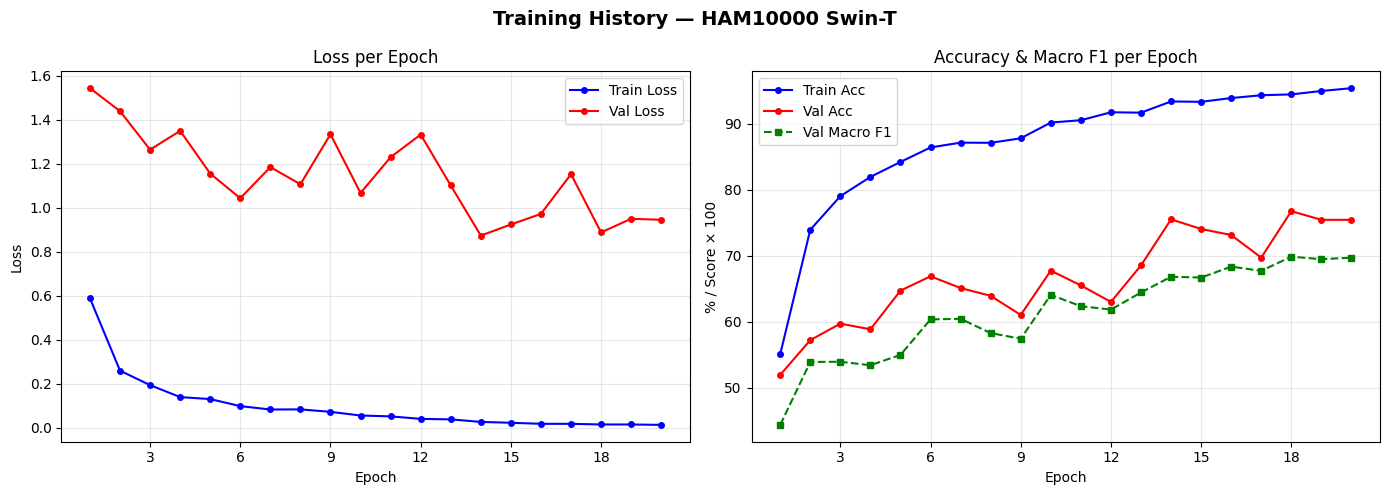

Training curves saved → /content/ham10000/outputs/training_curves.png


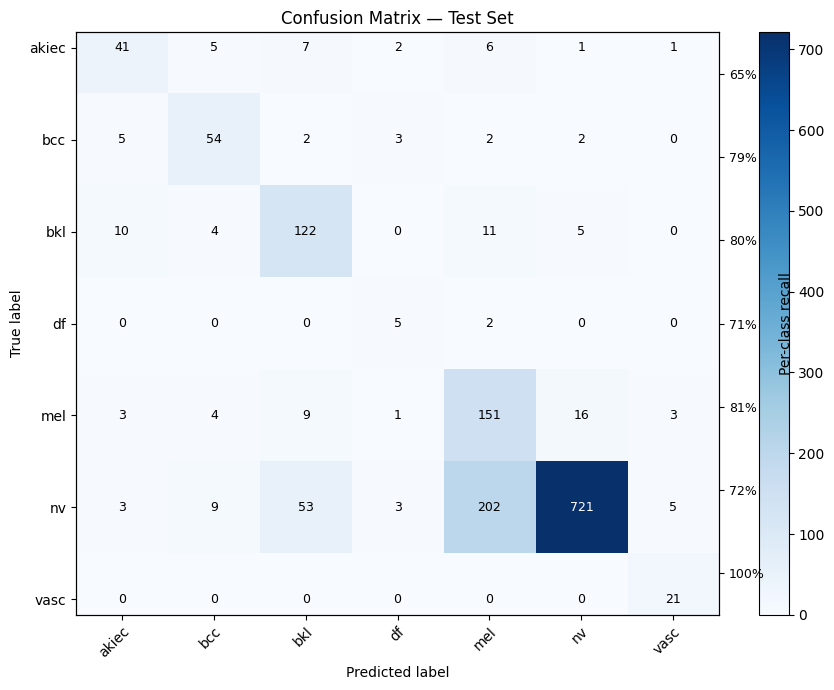

Confusion matrix saved → /content/ham10000/outputs/confusion_matrix_test.png


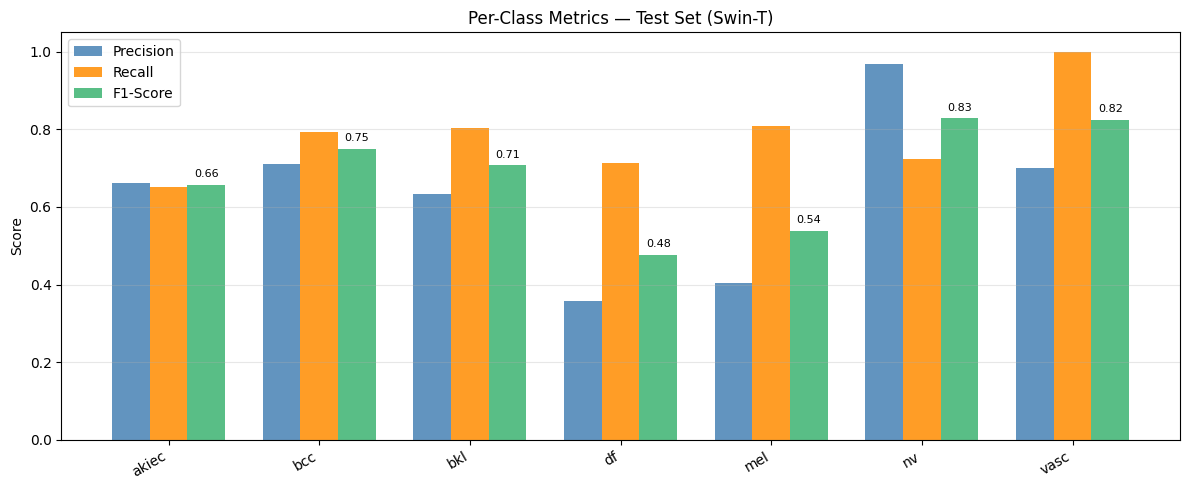

Per-class metrics saved → /content/ham10000/outputs/per_class_metrics_test.png

Generating 8 Grad-CAM overlays ...
  [✓] true=nv           pred=nv            → ISIC_0025424_true-nv_pred-nv.jpg
  [✗] true=mel          pred=nv            → ISIC_0034064_true-mel_pred-nv.jpg
  [✓] true=bkl          pred=bkl           → ISIC_0027218_true-bkl_pred-bkl.jpg
  [✓] true=nv           pred=nv            → ISIC_0032223_true-nv_pred-nv.jpg
  [✗] true=nv           pred=df            → ISIC_0024690_true-nv_pred-df.jpg
  [✓] true=nv           pred=nv            → ISIC_0027170_true-nv_pred-nv.jpg
  [✓] true=mel          pred=mel           → ISIC_0026500_true-mel_pred-mel.jpg
  [✓] true=mel          pred=mel           → ISIC_0033047_true-mel_pred-mel.jpg

All outputs saved to: /content/ham10000/outputs


In [ ]:
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cv2

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
DATA_DIR   = Path("/content/ham10000")
META_CSV   = DATA_DIR / "HAM10000_metadata.csv"

NUM_EPOCHS  = 20
BATCH_SIZE  = 16
LR          = 1e-4
IMG_SIZE    = 224
NUM_WORKERS = 2
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR  = DATA_DIR / "outputs"
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
GRADCAM_DIR = OUTPUT_DIR / "gradcam"

for d in [CKPT_DIR, GRADCAM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device : {DEVICE}")
print(f"Epochs : {NUM_EPOCHS}")
print(f"Batch  : {BATCH_SIZE}")


# ─────────────────────────────────────────
# 1. UNZIP
# ─────────────────────────────────────────
def unzip_if_needed(data_dir: Path):
    for base in ["HAM10000_images_part_1", "HAM10000_images_part_2",
                 "ham10000_images_part_1",  "ham10000_images_part_2"]:
        zip_path = data_dir / f"{base}.zip"
        out_dir  = data_dir / base
        if zip_path.exists() and not out_dir.exists():
            print(f"Unzipping {zip_path} ...")
            subprocess.run(
                ["unzip", "-q", str(zip_path), "-d", str(data_dir)],
                check=True
            )


# ─────────────────────────────────────────
# 2. METADATA & DATASET
# ─────────────────────────────────────────
def load_metadata(data_dir: Path):
    if not META_CSV.exists():
        raise FileNotFoundError(f"Metadata CSV not found: {META_CSV}")

    candidates = [
        data_dir / "HAM10000_images_part_1",
        data_dir / "ham10000_images_part_1",
        data_dir / "HAM10000_images_part_2",
        data_dir / "ham10000_images_part_2",
    ]
    img_dirs = [p for p in candidates if p.exists()]
    if not img_dirs:
        raise FileNotFoundError(f"No image folders found. Checked:\n{candidates}")
    print("Image directories:", img_dirs)

    df = pd.read_csv(META_CSV)

    def find_image(image_id):
        fname = f"{image_id}.jpg"
        for d in img_dirs:
            p = d / fname
            if p.exists():
                return str(p)
        return None

    df["image_path"] = df["image_id"].apply(find_image)
    missing = df["image_path"].isna().sum()
    print(f"Images found: {len(df) - missing}  |  Missing: {missing}")
    df = df[df["image_path"].notna()].reset_index(drop=True)

    labels       = sorted(df["dx"].unique())
    label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
    df["label_idx"] = df["dx"].map(label_to_idx)

    print("\nClasses:", label_to_idx)
    print("Class counts:\n", df["label_idx"].value_counts().sort_index())
    return df, label_to_idx, labels


class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label_idx"])
        path  = row["image_path"]
        img   = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path


def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tfms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tfms, test_tfms


def make_splits(df):
    """Patient-safe split on lesion_id — prevents data leakage."""
    groups = df["lesion_id"].values

    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss_outer.split(df, groups=groups))
    train_df = df.iloc[train_idx]
    temp_df  = df.iloc[temp_idx]

    gss_inner   = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    temp_groups = temp_df["lesion_id"].values
    val_idx, test_idx = next(gss_inner.split(temp_df, groups=temp_groups))
    val_df  = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

    print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))


def make_weighted_sampler(train_df):
    counts   = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    class_w  = 1.0 / counts
    sample_w = train_df["label_idx"].map(lambda i: class_w[i]).values
    return WeightedRandomSampler(
        weights     = torch.from_numpy(sample_w).float(),
        num_samples = len(train_df),
        replacement = True,
    )


# ─────────────────────────────────────────
# 3. MODEL
# ─────────────────────────────────────────
def build_model(num_classes):
    weights = Swin_T_Weights.IMAGENET1K_V1
    model   = swin_t(weights=weights)
    in_feat = model.head.in_features
    model.head = nn.Linear(in_feat, num_classes)
    return model


# ─────────────────────────────────────────
# 4. CLASS WEIGHTS
# ─────────────────────────────────────────
def compute_class_weights(train_df, num_classes):
    counts  = train_df["label_idx"].value_counts().sort_index().values.astype(np.float32)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    print("Loss class weights:", np.round(weights, 3))
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# ─────────────────────────────────────────
# 5. TRAIN / EVALUATE
# ─────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for imgs, labels, _ in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0
    all_labels   = []
    all_preds    = []

    criterion_eval = nn.CrossEntropyLoss()

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)
            loss    = criterion_eval(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    report     = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    conf_mat   = confusion_matrix(all_labels, all_preds)

    return running_loss / total, correct / total, report, conf_mat


# ─────────────────────────────────────────
# 6. PRINTING RESULTS
# ─────────────────────────────────────────
def print_report(report, labels, split="Test"):
    bar = "=" * 55
    print(f"\n{bar}")
    print(f"  {split} Results")
    print(bar)
    print(f"  {'Class':<22} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Sup':>6}")
    print(f"  {'-'*48}")
    for i, lbl in enumerate(labels):
        r = report[str(i)]
        print(
            f"  {lbl:<22} "
            f"{r['precision']:>6.3f} "
            f"{r['recall']:>6.3f} "
            f"{r['f1-score']:>6.3f} "
            f"{int(r['support']):>6}"
        )
    print(f"  {'-'*48}")
    print(f"  Accuracy          : {report['accuracy']:.4f}  ({report['accuracy']*100:.2f}%)")
    print(f"  Macro F1          : {report['macro avg']['f1-score']:.4f}")
    print(f"  Weighted F1       : {report['weighted avg']['f1-score']:.4f}")
    print(f"  Macro Precision   : {report['macro avg']['precision']:.4f}")
    print(f"  Macro Recall      : {report['macro avg']['recall']:.4f}")
    print(bar)


# ─────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────
def plot_training_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History — HAM10000 Swin-T", fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    ax.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Loss per Epoch"); ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, [a * 100 for a in history["train_acc"]],    "b-o",  label="Train Acc",    markersize=4)
    ax.plot(epochs, [a * 100 for a in history["val_acc"]],      "r-o",  label="Val Acc",      markersize=4)
    ax.plot(epochs, [f * 100 for f in history["val_macro_f1"]], "g--s", label="Val Macro F1", markersize=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("% / Score × 100")
    ax.set_title("Accuracy & Macro F1 per Epoch"); ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {save_path}")


def plot_confusion_matrix(cm, labels, save_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(len(labels)),
        yticks      = np.arange(len(labels)),
        xticklabels = labels,
        yticklabels = labels,
        ylabel      = "True label",
        xlabel      = "Predicted label",
        title       = "Confusion Matrix — Test Set",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > thresh else "black")

    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(np.arange(len(labels)))
    ax2.set_yticklabels([f"{a:.0%}" for a in per_class_acc], fontsize=9)
    ax2.set_ylabel("Per-class recall", labelpad=10)

    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix saved → {save_path}")


def plot_per_class_bar(report, labels, save_path):
    x     = np.arange(len(labels))
    width = 0.25
    prec  = [report[str(i)]["precision"] for i in range(len(labels))]
    rec   = [report[str(i)]["recall"]    for i in range(len(labels))]
    f1s   = [report[str(i)]["f1-score"]  for i in range(len(labels))]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec, width, label="Precision",  color="steelblue",      alpha=0.85)
    ax.bar(x,          rec,  width, label="Recall",     color="darkorange",     alpha=0.85)
    ax.bar(x + width, f1s,  width, label="F1-Score",   color="mediumseagreen", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Metrics — Test Set (Swin-T)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    for i, v in enumerate(f1s):
        ax.text(x[i] + width, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Per-class metrics saved → {save_path}")


# ─────────────────────────────────────────
# 8. GRAD-CAM for Swin Transformer
#
#  KEY FACT (verified by inspection):
#    model.norm output shape = (B, 7, 7, 768)   ← 4D, NOT (B, N, C)
#
#  OLD (WRONG) code assumed (B, N, C) and did:
#    weights = grad.mean(dim=1)       → averaged over H=7, not channels!
#    cam = (weights * act).sum(dim=-1)→ completely wrong result
#
#  CORRECT approach:
#    weights = grad.mean(dim=(1,2))   → global spatial avg → (B, 1, 1, C)
#    cam = (weights * act).sum(dim=-1)→ sum over channels  → (B, H, W)
# ─────────────────────────────────────────
class SwinGradCAM:
    """
    Grad-CAM for Swin Transformer Tiny.
    Hooks model.norm — the LayerNorm before avgpool+head.
    Verified output shape: (B, 7, 7, 768) for 224px input.
    """
    def __init__(self, model):
        self.model      = model
        self.gradient   = None
        self.activation = None

        self.model.norm.register_forward_hook(self._forward_hook)
        self.model.norm.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        # out shape: (B, 7, 7, 768)
        self.activation = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        # grad_out[0] shape: (B, 7, 7, 768)
        self.gradient = grad_out[0].detach()

    def generate(self, input_tensor, target_class=None):
        """Returns (cam numpy H×W, predicted_class_idx)."""
        self.model.eval()
        with torch.enable_grad():
            self.model.zero_grad()
            output = self.model(input_tensor)

            if target_class is None:
                target_class = output.argmax(dim=1).item()

            output[0, target_class].backward()

        grad = self.gradient    # (1, 7, 7, 768)
        act  = self.activation  # (1, 7, 7, 768)

        # FIX: average gradient over spatial dims (H, W), not over H alone
        weights = grad.mean(dim=(1, 2), keepdim=True)   # (1, 1, 1, 768)

        # Weighted sum over channel dim → spatial activation map
        cam = (weights * act).sum(dim=-1)               # (1, 7, 7)
        cam = torch.relu(cam).squeeze(0)                # (7, 7)

        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), target_class


def overlay_gradcam(img_tensor, cam_np, save_path, img_size=224):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    heatmap = cv2.resize(cam_np, (img_size, img_size))
    heatmap = (heatmap * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.55, heatmap, 0.45, 0)
    cv2.imwrite(str(save_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


def generate_gradcam_examples(model, dataset, labels, num_samples=8):
    gradcam = SwinGradCAM(model)
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    print(f"\nGenerating {len(indices)} Grad-CAM overlays ...")
    for idx in indices:
        img_tensor, true_label, path = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        cam_np, pred_class = gradcam.generate(input_tensor)

        stem      = Path(path).stem
        save_path = GRADCAM_DIR / (
            f"{stem}_true-{labels[true_label]}_pred-{labels[pred_class]}.jpg"
        )
        overlay_gradcam(img_tensor, cam_np, save_path)
        status = "✓" if pred_class == true_label else "✗"
        print(f"  [{status}] true={labels[true_label]:<12} pred={labels[pred_class]:<12}  → {save_path.name}")


# ─────────────────────────────────────────
# 9. MAIN
# ─────────────────────────────────────────
def main():
    unzip_if_needed(DATA_DIR)
    df, label_to_idx, labels = load_metadata(DATA_DIR)
    num_classes = len(labels)

    train_df, val_df, test_df = make_splits(df)

    train_tfms, test_tfms = get_transforms()
    train_dataset = SkinDataset(train_df, transform=train_tfms)
    val_dataset   = SkinDataset(val_df,   transform=test_tfms)
    test_dataset  = SkinDataset(test_df,  transform=test_tfms)

    sampler = make_weighted_sampler(train_df)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True,
    )
    val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model         = build_model(num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_df, num_classes)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    optimizer     = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_macro_f1 = 0.0
    best_ckpt = CKPT_DIR / "swin_t_ham10000_best.pth"

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "val_macro_f1": [],
    }

    print(f"\n{'─'*65}")
    print(f"  Training Swin-T for {NUM_EPOCHS} epochs on {DEVICE}")
    print(f"{'─'*65}")
    print(f"  {'Ep':>3}  {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlF1':>7}  LR")

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc                = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_report, _ = evaluate(model, val_loader)
        vl_macro_f1                   = vl_report["macro avg"]["f1-score"]

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_macro_f1"].append(vl_macro_f1)

        marker = " ★" if vl_macro_f1 > best_val_macro_f1 else ""
        print(
            f"  {epoch:>3}  {tr_loss:>8.4f} {tr_acc*100:>6.2f}%"
            f" {vl_loss:>8.4f} {vl_acc*100:>6.2f}%"
            f" {vl_macro_f1:>7.4f}  {current_lr:.2e}{marker}"
        )

        if vl_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = vl_macro_f1
            torch.save(model.state_dict(), best_ckpt)

    print(f"\nBest val macro F1 : {best_val_macro_f1:.4f}")
    print(f"Checkpoint saved  : {best_ckpt}")

    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))

    _, test_acc, test_report, test_cm = evaluate(model, test_loader)
    print_report(test_report, labels, split="Test")

    plot_training_curves(history,          save_path=OUTPUT_DIR / "training_curves.png")
    plot_confusion_matrix(test_cm, labels, save_path=OUTPUT_DIR / "confusion_matrix_test.png")
    plot_per_class_bar(test_report, labels, save_path=OUTPUT_DIR / "per_class_metrics_test.png")

    generate_gradcam_examples(model, test_dataset, labels, num_samples=8)

    print("\nAll outputs saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()